# Axicon-3 central Bessel lobe — jul22–23 dataset (candidate #1)

J$_0^2$ fits of the central-lobe core frames for the **candidate #1 baseline**
configuration (L$_{12}$ = 190 mm, L$_{23}$ = 50 mm, D = 4.59 mm, 5°/5°/0.5°,
650 nm) — the jul22–23 window scan that previously only had the on-axis
aperture reduction (`onaxis_reduction_2026_07_23.json`). Mirrors
`axicon3_central_bessel_lobe_2026_07_30` / the aug6 notebooks: manifest-only
core pick → cached thumbnails → radial + X/Z chord J$_0^2$ fits → k ladder →
fits-based axial envelope and measured window for the final report.

17 runs, placements jul22-001 … jul23-012, y = 7–177 cm (0.5 cm pitch in the
window region; model window ≈ 1.39–1.76 m). Frames 1536×2048 uint8 (sat 255).
Pre-window slices (y ≲ 120) are annulus/fringe light, not a core — their
frames fail the rms cut and drop out of the fits-based axial naturally.

Caches (shared schema with the aug6 notebooks; pre-built device-side by
`_to_delete/jul23_core_cache/build_jul23_core_cache.py`, same algorithm):
`reductions/ax3_core_frames_2026_07_23.csv`,
`reductions/ax3_core_thumbs_2026_07_23.npz` — delete the npz for a full
rebuild from raw.

In [1]:
import csv
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
RED = Path("reductions")

for _name in ("bessel_beam_webapp",):  # NB trailing comma: bare ("x") iterates characters
    if (REPO.parent / _name).exists():
        sys.path.insert(0, str(REPO.parent / _name))
        break
from simulator.qdht_axicon import axicon_kr

PX_UM = 3.45
HALF_PX, POOL = 144, 2
UM_PER_PX = POOL * PX_UM            # 6.9 um/px thumbnails
FIT_HALF_UM = 450.0
KR_IDEAL = axicon_kr(0.5)           # ideal axicon-3 k_r (650 nm, n=1.4585)
CORE_RATIO_MIN = 0.5
RMS_OK = 0.06

CSV_P = RED / "ax3_core_frames_2026_07_23.csv"
NPZ_P = RED / "ax3_core_thumbs_2026_07_23.npz"

NOTEBOOK_STEM = "axicon3_central_bessel_lobe_2026_07_23"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

In [2]:
# --- core-frame list (manifest-only, cached) ---------------------------------
#   1. jul22/23 run dirs with a frames.jsonl (all are candidate #1 window
#      scans; bad/truncated manifest lines skipped with a warning)
#   2. keep ScanKind == "AutoBeamStack"; per slice, frame rate = Max /
#      Exposure_us; core candidate if rate >= 0.5 x slice best
#   3. saturated frames kept in the CSV, flagged n_sat_px > 0
# On a machine without profiler/data (or with the CSV complete) the cached
# CSV is used as-is.
COLS = ["beam_y_cm", "run", "slice", "frame", "gantry_x_mm", "gantry_z_mm",
        "max_counts", "exposure_us", "rate_c_per_us", "ratio_to_slice_best",
        "n_sat_px", "excluded_run"]
EXCLUDED_RUNS = set()

run_dirs = sorted((REPO / "profiler/data").glob("auto_scan-2026-07-2[23]_*"))
have = set()
if CSV_P.exists():
    have = {(r["run"], r["frame"]) for r in csv.DictReader(open(CSV_P))}
elif not run_dirs:
    raise FileNotFoundError(f"no {CSV_P} and no profiler/data manifests")

new_rows = []
for run_dir in run_dirs:
    slices = {}
    for ln, line in enumerate(open(run_dir / "frames.jsonl")):
        line = line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            print(f"WARNING {run_dir.name}: bad manifest line {ln} skipped")
            continue
        ex = rec.get("Extra", {})
        if ex.get("ScanKind") == "AutoBeamStack":
            slices.setdefault(ex["Subfolder"], []).append((rec, ex))
    for sl, recs in sorted(slices.items()):
        best = max(r["Max"] / e["Exposure_us"] for r, e in recs)
        for rec, ex in recs:
            rate = rec["Max"] / ex["Exposure_us"]
            frame = Path(rec["Path"]).name
            if rate < CORE_RATIO_MIN * best or (run_dir.name, frame) in have:
                continue
            g = rec["GantryPosition_mm"]
            new_rows.append([ex["BeamY_mm"] / 10.0, run_dir.name, sl, frame,
                             g["x_mm"], g["z_mm"], rec["Max"],
                             round(ex["Exposure_us"], 1), round(rate, 4),
                             round(rate / best, 3),
                             rec["SaturatedPixelCount"],
                             run_dir.name in EXCLUDED_RUNS])
if new_rows:
    write_header = not CSV_P.exists()
    with open(CSV_P, "a", newline="") as f:
        w = csv.writer(f)
        if write_header:
            w.writerow(COLS)
        w.writerows(new_rows)
    print(f"appended {len(new_rows)} new core rows")

core_df = [r for r in csv.DictReader(open(CSV_P))
           if r["excluded_run"] == "False"]
ys_all = sorted({float(r["beam_y_cm"]) for r in core_df})
n_sat = sum(int(r["n_sat_px"]) > 0 for r in core_df)
print(f"{len(core_df)} core candidates over {len(ys_all)} slices "
      f"(y {ys_all[0]:.1f}-{ys_all[-1]:.1f} cm), {n_sat} saturated")

1105 core candidates over 186 slices (y 7.0-177.0 cm), 50 saturated


In [3]:
# --- core thumbnails (incremental cache) -------------------------------------
#   eligible = unsaturated candidates; +-144 px crop about the raw-frame
#   argmax (NaN off-sensor), 2x2 mean pool -> 144x144 float16 raw counts.
#   Missing (run, frame) pairs are appended from raw; todo = 0 when the
#   device-built cache is complete (no raw frames needed).
if NPZ_P.exists():
    _z = np.load(NPZ_P, allow_pickle=True)
    T, Y = _z["thumbs"], _z["ys_cm"]
    R, F = _z["runs"], _z["frames"]
    print(f"loaded cached thumbnails {T.shape}")
else:
    T = np.zeros((0, 2 * HALF_PX // POOL, 2 * HALF_PX // POOL), np.float16)
    Y = np.zeros(0); R = F = np.zeros(0, dtype="U120")

have_t = set(zip(R.tolist(), F.tolist()))
todo = [r for r in core_df
        if int(r["n_sat_px"]) == 0 and (r["run"], r["frame"]) not in have_t]
print(f"todo = {len(todo)}")
if todo:
    new_t, new_y, new_r, new_f = [], [], [], []
    for r in todo:
        p = REPO / "profiler/data" / r["run"] / r["slice"] / r["frame"]
        if not p.exists():
            print(f"MISSING raw frame {p} — left out")
            continue
        a = np.load(p).astype(np.float32)
        iy, ix = np.unravel_index(np.argmax(a), a.shape)
        c = np.full((2 * HALF_PX, 2 * HALF_PX), np.nan, np.float32)
        y0, y1 = max(iy - HALF_PX, 0), min(iy + HALF_PX, a.shape[0])
        x0, x1 = max(ix - HALF_PX, 0), min(ix + HALF_PX, a.shape[1])
        c[y0 - iy + HALF_PX:y1 - iy + HALF_PX,
          x0 - ix + HALF_PX:x1 - ix + HALF_PX] = a[y0:y1, x0:x1]
        t = c.reshape(c.shape[0] // POOL, POOL, -1, POOL).mean((1, 3))
        new_t.append(t.astype(np.float16))
        new_y.append(float(r["beam_y_cm"]))
        new_r.append(r["run"]); new_f.append(r["frame"])
    T = np.concatenate([T, np.array(new_t, np.float16)])
    Y = np.concatenate([Y, np.array(new_y)])
    R = np.concatenate([R.astype("U120"), np.array(new_r, dtype="U120")])
    F = np.concatenate([F.astype("U120"), np.array(new_f, dtype="U120")])
    np.savez_compressed(NPZ_P, thumbs=T, ys_cm=Y, runs=R, frames=F,
                        half_um=HALF_PX * PX_UM, um_per_px=UM_PER_PX)
    print(f"cache now {len(T)} thumbs")

EXPOSURE = {(r["run"], r["frame"]): float(r["exposure_us"]) for r in core_df}

loaded cached thumbnails (1055, 144, 144)
todo = 0


saved images/axicon3_central_bessel_lobe_2026_07_23/core_gallery_v1.png


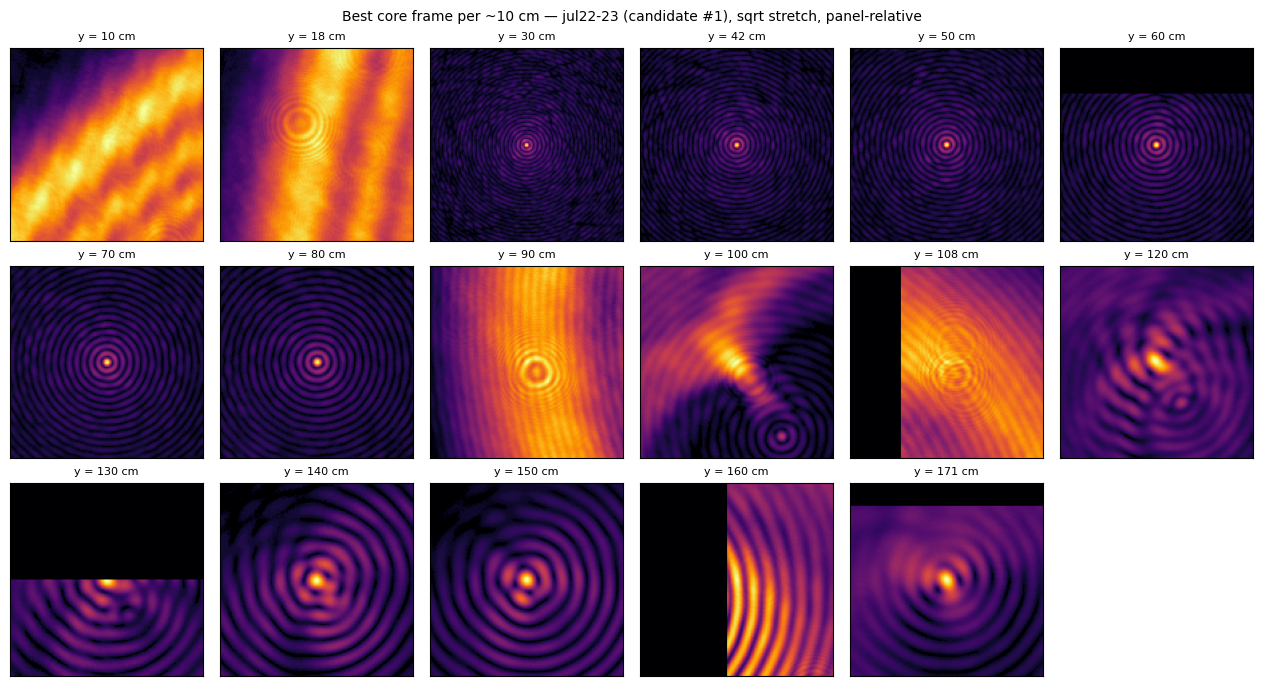

In [4]:
# --- v1 gallery: best-rate frame per y, every ~10 cm -------------------------
# sqrt stretch, each panel to its own peak; pre-window panels show the
# annulus fringe pattern rather than a core (expected).
RATE = {(r["run"], r["frame"]): float(r["rate_c_per_us"]) for r in core_df}
by_y = {}
for t, y, run, fr in zip(T, Y, R, F):
    key = float(y)
    rate = RATE.get((str(run), str(fr)), 0.0)
    if key not in by_y or rate > by_y[key][0]:
        by_y[key] = (rate, t)

targets = [y for y in np.arange(10, 180, 10.0)]
picks = []
for yt in targets:
    ys_near = min(by_y, key=lambda y: abs(y - yt))
    if abs(ys_near - yt) <= 2.5:
        picks.append((ys_near, by_y[ys_near][1]))

n = len(picks)
ncols = 6
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(2.1 * ncols, 2.25 * nrows),
                         layout="constrained")
for ax in axes.ravel():
    ax.axis("off")
for ax, (y, t) in zip(axes.ravel(), picks):
    img = np.asarray(t, dtype=np.float32)
    ax.imshow(np.sqrt(np.nan_to_num(img / np.nanmax(img))), cmap="inferno",
              extent=[-HALF_PX * PX_UM, HALF_PX * PX_UM,
                      -HALF_PX * PX_UM, HALF_PX * PX_UM])
    ax.set_title(f"y = {y:.0f} cm", fontsize=8)
    ax.axis("on"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Best core frame per ~10 cm — jul22-23 (candidate #1), "
             "sqrt stretch, panel-relative", fontsize=10)
save_fig("core_gallery_v1")
plt.show()

In [5]:
# --- 1D J0^2 fits: radial + X/Z chords ---------------------------------------
# Per fills-the-square thumb (any NaN = clipped -> skipped): sub-pixel
# centroid, azimuthal-mean radial profile (u0 fixed 0) and X/Z lineouts
# through the core (free center, |u0| <= 35 um); each fit
# A*J0^2(k(u-u0)) + C over |u| <= 450 um, k bounded 0.2-4x ideal.
from scipy.optimize import curve_fit
from scipy.special import j0


def j0sq_c(u_um, A, k, u0_um, C):
    return A * j0(k * (u_um - u0_um) * 1e-6) ** 2 + C


def centroid(t):
    s = t.copy()
    s[1:-1, 1:-1] = (t[:-2, :-2] + t[:-2, 1:-1] + t[:-2, 2:] +
                     t[1:-1, :-2] + t[1:-1, 1:-1] + t[1:-1, 2:] +
                     t[2:, :-2] + t[2:, 1:-1] + t[2:, 2:]) / 9.0
    iy, ix = np.unravel_index(np.argmax(s), s.shape)
    y0, y1 = max(iy - 7, 0), min(iy + 8, t.shape[0])
    x0, x1 = max(ix - 7, 0), min(ix + 8, t.shape[1])
    w = t[y0:y1, x0:x1]
    yy, xx = np.mgrid[y0:y1, x0:x1]
    return (w * yy).sum() / w.sum(), (w * xx).sum() / w.sum()


def fit_1d(u, I, free_center):
    ok = np.isfinite(I) & (np.abs(u) <= FIT_HALF_UM)
    p0 = [np.nanmax(I[ok]), KR_IDEAL, 0.0, 0.0]
    u0m = 35.0 if free_center else 1e-9
    popt, pcov = curve_fit(j0sq_c, u[ok], I[ok], p0=p0,
                           bounds=([0, 0.2 * KR_IDEAL, -u0m, -np.inf],
                                   [np.inf, 4.0 * KR_IDEAL, u0m, np.inf]))
    perr = np.sqrt(np.diag(pcov))
    rms = np.sqrt(np.mean((I[ok] - j0sq_c(u[ok], *popt)) ** 2)) / popt[0]
    return popt, perr, rms


FITS = []
n_clip = n_fail = 0
for t, y, run, fr in zip(T, Y, R, F):
    t32 = np.asarray(t, dtype=np.float32)
    if np.isnan(t32).any():
        n_clip += 1
        continue
    cy, cx = centroid(t32)
    iy, ix = int(round(cy)), int(round(cx))
    u = (np.arange(t32.shape[0]) - cy) * UM_PER_PX
    yy, xx = np.mgrid[:t32.shape[0], :t32.shape[1]]
    nb_ = np.round(np.hypot(yy - cy, xx - cx) * 2).astype(int)
    with np.errstate(invalid="ignore"):
        prof = (np.bincount(nb_.ravel(), t32.ravel())
                / np.bincount(nb_.ravel()))
    u_r = np.arange(len(prof)) * 0.5 * UM_PER_PX
    try:
        pr, er, rms_r = fit_1d(u_r, prof, free_center=False)
        px_, ex_, rms_x = fit_1d((np.arange(t32.shape[1]) - cx) * UM_PER_PX,
                                 t32[iy, :], free_center=True)
        pz_, ez_, rms_z = fit_1d((np.arange(t32.shape[0]) - cy) * UM_PER_PX,
                                 t32[:, ix], free_center=True)
    except RuntimeError:
        n_fail += 1
        continue
    FITS.append(dict(y=float(y), run=str(run), frame=str(fr),
                     T_us=EXPOSURE.get((str(run), str(fr)), np.nan),
                     pr=pr, er=er, rms_r=rms_r, px=px_, rms_x=rms_x,
                     pz=pz_, rms_z=rms_z, u_r=u_r, prof=prof))
clean = [f for f in FITS if f["rms_r"] <= RMS_OK]
k_med = np.median([f["pr"][1] for f in clean]) / KR_IDEAL
print(f"{len(FITS)} fits ({n_clip} clipped, {n_fail} failed); "
      f"{len(clean)} clean (rms_r <= {RMS_OK}); "
      f"clean k_r median {100 * (k_med - 1):+.1f}% vs ideal")

651 fits (402 clipped, 2 failed); 202 clean (rms_r <= 0.06); clean k_r median -0.3% vs ideal


saved images/axicon3_central_bessel_lobe_2026_07_23/core_fit_k_vs_y.png


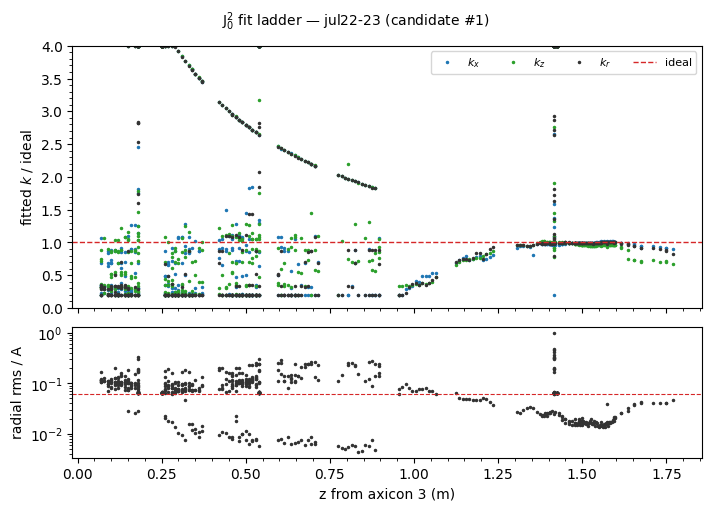

In [6]:
# --- k / ideal vs y ----------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                               height_ratios=[2, 1], layout="constrained")
ys_f = np.array([f["y"] for f in FITS])
for key, col, lab in (("px", "tab:blue", "$k_x$"),
                      ("pz", "tab:green", "$k_z$"),
                      ("pr", "0.2", "$k_r$")):
    ax1.plot(ys_f / 100, [f[key][1] / KR_IDEAL for f in FITS], ".", ms=3,
             color=col, label=lab)
ax1.axhline(1.0, color="tab:red", ls="--", lw=1, label="ideal")
ax1.set_ylabel("fitted $k$ / ideal")
ax1.set_ylim(0, 4)
ax1.legend(fontsize=8, ncol=4)
ax1.minorticks_on()
ax2.plot(ys_f / 100, [f["rms_r"] for f in FITS], ".", ms=3, color="0.2")
ax2.axhline(RMS_OK, color="tab:red", ls="--", lw=0.8)
ax2.set_xlabel("z from axicon 3 (m)")
ax2.set_ylabel("radial rms / A")
ax2.set_yscale("log")
ax2.minorticks_on()
fig.suptitle("J$_0^2$ fit ladder — jul22-23 (candidate #1)", fontsize=10)
save_fig("core_fit_k_vs_y")
plt.show()

peak 0.723 c/us at 1.48 m; deepest in-window ripple 52% of peak
  peak : 0.38 ($z \in [1.29, 1.68]$)
  outer: 0.38 ($z \in [1.29, 1.68]$)


saved images/axicon3_central_bessel_lobe_2026_07_23/fits_axial_window.png


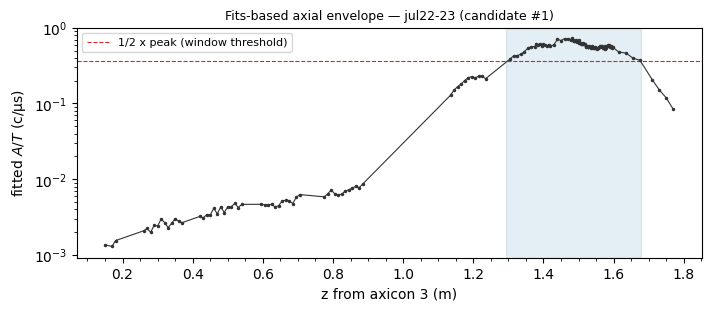

In [7]:
# --- fits-based axial envelope + measured window (report numbers) ------------
# Envelope: per y, largest fitted A/T among clean fits. Windows: from-peak
# FWHM and outermost 50% crossings (identical for a well-behaved envelope),
# printed in the report format L ($z \in [lo, hi]$).
best = {}
for f in clean:
    rate = f["pr"][0] / f["T_us"]
    err = f["er"][0] / f["T_us"]
    if f["y"] not in best or rate > best[f["y"]][0]:
        best[f["y"]] = (rate, err)
ys_e = np.array(sorted(best))
I_e = np.array([best[y][0] for y in ys_e])
E_e = np.array([best[y][1] for y in ys_e])


def crossings(ys, I):
    i = int(np.argmax(I))
    half = 0.5 * I[i]
    out = {}
    for mode in ("peak", "outer"):
        lo = hi = None
        if mode == "peak":
            for j in range(i, -1, -1):
                if I[j] < half:
                    lo = np.interp(half, [I[j], I[j + 1]], [ys[j], ys[j + 1]])
                    break
            for j in range(i, len(I)):
                if I[j] < half:
                    hi = np.interp(half, [I[j], I[j - 1]], [ys[j], ys[j - 1]])
                    break
        else:
            above = I >= half
            j = int(np.argmax(above))
            if j > 0:
                lo = np.interp(half, [I[j - 1], I[j]], [ys[j - 1], ys[j]])
            j = len(I) - 1 - int(np.argmax(above[::-1]))
            if j < len(I) - 1:
                hi = np.interp(half, [I[j + 1], I[j]], [ys[j + 1], ys[j]])
        out[mode] = (lo, hi)
    inw = slice(None)
    lo, hi = out["outer"]
    m = (ys >= (lo or ys[0])) & (ys <= (hi or ys[-1]))
    return half, ys[i], I[i], out, I[m].min() / I[i]


half, y_pk, I_pk, wins, ripple = crossings(ys_e, I_e)
print(f"peak {I_pk:.3f} c/us at {y_pk / 100:.2f} m; "
      f"deepest in-window ripple {100 * ripple:.0f}% of peak")
for mode, (lo, hi) in wins.items():
    if lo is not None and hi is not None:
        print(f"  {mode:5s}: {(hi - lo) / 100:.2f} "
              f"($z \\in [{lo / 100:.2f}, {hi / 100:.2f}]$)")
    else:
        print(f"  {mode:5s}: UNBOUNDED [{lo}, {hi}]")

fig, ax = plt.subplots(figsize=(7, 3), layout="constrained")
ax.errorbar(ys_e / 100, I_e, yerr=E_e, fmt=".-", ms=3, lw=0.8, color="0.2",
            elinewidth=0.6)
ax.axhline(half, color="tab:red", lw=0.8, ls="--",
           label="1/2 x peak (window threshold)")
lo, hi = wins["outer"]
if lo is not None and hi is not None:
    ax.axvspan(lo / 100, hi / 100, color="tab:blue", alpha=0.12)
ax.set_xlabel("z from axicon 3 (m)")
ax.set_ylabel("fitted $A/T$ (c/µs)")
ax.set_yscale("log")
ax.minorticks_on()
ax.legend(fontsize=8)
ax.set_title("Fits-based axial envelope — jul22-23 (candidate #1)",
             fontsize=9)
save_fig("fits_axial_window")
plt.show()